# Introduction to Data Science 2025

# Week 6: Recap

## Exercise 1 | Linear regression with feature selection

Download the [TED Talks](https://www.kaggle.com/rounakbanik/ted-talks) dataset from Kaggle. Your task is to predict both the ratings and the number of views of a given TED talk. You should focus only on the <span style="font-weight: bold">ted_main</span> table.

1. Download the data, extract the following ratings from column <span style="font-weight: bold">ratings</span>: <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, <span style="font-weight: bold">Inspiring</span>. Store these values into respective columns so that they are easier to access. Next, extract the tags from column <span style="font-weight: bold">tags</span>. Count the number of occurrences of each tag and select the top-100 most common tags. Create a binary variable for each of these and include them in your data table, so that you can directly see whether a given tag (among the top-100 tags) is used in a given TED talk or not. The dataset you compose should have dimension (2550, 104), and comprise of the 'views' column, the three columns with counts of "Funny", "Confusing and "Inspiring" ratings, and 100 columns which one-hot encode the top-100 most common tag columns.


In [1]:
# Use this cell for your code

#select funny, confusing, inspiring from ratings

#read data
import os
os.environ["TPOT_USE_DASK"] = "False"

from tpot import TPOTClassifier
import pandas as pd
import numpy as np
import ast
from collections import Counter

ted_main=pd.read_csv("ted_main.csv")
transcripts=pd.read_csv("transcripts.csv")
ted_main.describe()
ted_main['ratings'] = ted_main.ratings.apply(lambda x: ast.literal_eval(x))
ted_main.head


def get_rating_count(ratings_list, name):
    for ratings_dict in ratings_list:
        if ratings_dict['name']==name:
            return ratings_dict['count']
    return 0

ted_main['Funny'] = ted_main['ratings'].apply(lambda x: get_rating_count(x, 'Funny'))
ted_main['Confusing'] = ted_main['ratings'].apply(lambda x: get_rating_count(x, 'Confusing'))
ted_main['Inspiring'] = ted_main['ratings'].apply(lambda x: get_rating_count(x, 'Inspiring'))

#extract tags, count occurence of each tag, select top 100, create binary variable for each of them, include in data (1 in ted talk, 0 not in ted talk?)
ted_main['tags'] = ted_main.tags.apply(lambda x: ast.literal_eval(x))

all_tags = []
for tags_list in ted_main['tags']:
    all_tags.extend(tags_list)
tag_counts = Counter(all_tags)
top_100_tags = [tag for tag, count in tag_counts.most_common(100)]
for tag in top_100_tags:
    ted_main[tag] = ted_main['tags'].apply(lambda x: 1 if tag in x else 0)

cols = ['views', 'Funny', 'Confusing', 'Inspiring'] + top_100_tags
data = ted_main[cols]

print(f"Dataset shape: {data.shape}")

print(data.head(5))


/Users/nawara/Documents/exchange/introDS/venv/lib/python3.13/site-packages/stopit/__init__.py:10: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/Users/nawara/Documents/exchange/introDS/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset shape: (2550, 104)
      views  Funny  Confusing  Inspiring  technology  science  global issues  \
0  47227110  19645        242      24924           0        0              0   
1   3200520    544         62        413           1        1              1   
2   1636292    964         27        230           1        0              0   
3   1697550     59         32       1070           0        0              0   
4  12005869   1390         72       2893           0        0              1   

   culture  TEDx  design  ...  food  religion  peace  ecology  family  demo  \
0        1     0       0  ...     0         0      0        0       0     0   
1        1     0       0  ...     0         0      0        0       0     0   
2        0     0       0  ...     0         0      0        0       0     0   
3        0     0       0  ...     0         0      0        0       0     0   
4        0     0       0  ...     0         0      0        0       0     1   

   poetry  illnes

/var/folders/9z/53zrw1q9321cl12bvyjv92g00000gn/T/ipykernel_57011/2861575164.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ted_main[tag] = ted_main['tags'].apply(lambda x: 1 if tag in x else 0)
/var/folders/9z/53zrw1q9321cl12bvyjv92g00000gn/T/ipykernel_57011/2861575164.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  ted_main[tag] = ted_main['tags'].apply(lambda x: 1 if tag in x else 0)
/var/folders/9z/53zrw1q9321cl12bvyjv92g00000gn/T/ipykernel_57011/2861575164.py:41: PerformanceWarning: DataFrame is highly fragmented.

2. Construct a linear regression model to predict the number of views based on the data in the <span style="font-weight: bold">ted_main</span> table, including the binary variables for the top-100 tags that you just created.

In [2]:
#views: to predict
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



X = data.drop('views', axis=1)
y = data['views'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficient (Slope):", model.coef_[0])
print("Intercept:", model.intercept_)

y_pred = model.predict(X_test)
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions.head())


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared Score:", r2)

Coefficient (Slope): 1089.4385935815892
Intercept: 893418.1482211663
       Actual     Predicted
56     684519  9.478343e+05
194    807628  2.385782e+06
2225  1173235  6.758708e+05
233    230569  8.231073e+05
1902  2647157  1.977346e+06
Mean Absolute Error (MAE): 616880.0941729482
Mean Squared Error (MSE): 1262207733226.4236
R-squared Score: 0.6749469552136265


3. Do the same for the <span style="font-weight: bold">Funny</span>, <span style="font-weight: bold">Confusing</span>, and <span style="font-weight: bold">Inspiring</span> ratings.

In [3]:
X_funny = data.drop('Funny', axis=1)
y_funny = data['Funny']

X_train, X_test, y_train, y_test = train_test_split(X_funny, y_funny, test_size=0.2, random_state=42)

model_funny = LinearRegression()
model_funny.fit(X_train, y_train) 

y_pred = model_funny.predict(X_test)
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions.head())

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared Score:", r2)

      Actual   Predicted
56        20   10.886680
194     1637  825.952642
2225      10  122.748369
233        5 -138.193065
1902      16  285.916894
Mean Absolute Error (MAE): 161.1014849819295
Mean Squared Error (MSE): 81521.12616648008
R-squared Score: 0.3928991839539122


In [4]:
X_confusing = data.drop('Confusing', axis=1)
y_confusing = data['Confusing']

X_train, X_test, y_train, y_test = train_test_split(X_confusing, y_confusing, test_size=0.2, random_state=42)

model_confusing = LinearRegression()
model_confusing.fit(X_train, y_train)

y_pred = model_confusing.predict(X_test)
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions.head())

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared Score:", r2)

      Actual  Predicted
56         5  25.694699
194        6  40.988530
2225       2  12.356172
233       16  12.075186
1902      17  22.411416
Mean Absolute Error (MAE): 14.642045904123934
Mean Squared Error (MSE): 665.8126722454384
R-squared Score: 0.2646457405621856


In [5]:
X_inspiring = data.drop('Inspiring', axis=1)
y_inspiring = data['Inspiring']

X_train, X_test, y_train, y_test = train_test_split(X_inspiring, y_inspiring, test_size=0.2, random_state=42)

model_inspiring = LinearRegression()
model_inspiring.fit(X_train, y_train)

y_pred = model_inspiring.predict(X_test)
predictions = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(predictions.head())

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R-squared Score:", r2)

      Actual    Predicted
56        94  -200.650800
194       57  -399.413175
2225     585   497.648581
233       70   -81.752920
1902     845  1315.343819
Mean Absolute Error (MAE): 362.08996629462916
Mean Squared Error (MSE): 407400.3917417199
R-squared Score: 0.5563430793022437


4. You will probably notice that most of the tags are not useful in predicting the views and the ratings. You should use some kind of variable selection to prune the set of tags that are included in the model. You can use for example classical p-values or more modern [LASSO](https://en.wikipedia.org/wiki/Lasso_(statistics)) techniques. Which tags are the best predictors of each of the response variables?

In [6]:
# Use this cell for your code
#pvals, views
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

X = data.drop(['views', 'Funny', 'Confusing', 'Inspiring'], axis=1)
feature_names = X.columns.tolist()

y_views = data['views']
X_with_const = sm.add_constant(X)
model_ols = sm.OLS(y_views, X_with_const).fit()
#significant vals are where pval<alpha
p_values = model_ols.pvalues[1:]
significant_features = p_values[p_values < 0.05].sort_values()

print("nbr of significant features: ",len(significant_features))
print(significant_features.head(10))

#pvals, funny
X_funny = data.drop('Funny', axis=1)
y_funny = data['Funny']
X_with_const = sm.add_constant(X_funny)
model_ols = sm.OLS(y_funny, X_with_const).fit()
p_values = model_ols.pvalues[1:]
significant_features = p_values[p_values < 0.05].sort_values()
print("\nFUNNY")
print("nbr of significant features: ",len(significant_features))
print(significant_features.head(10))

#pvals, confusing
X_confusing = data.drop('Confusing', axis=1)
y_confusing = data['Confusing']
X_with_const = sm.add_constant(X_confusing)
model_ols = sm.OLS(y_confusing, X_with_const).fit()
p_values = model_ols.pvalues[1:]
significant_features = p_values[p_values < 0.05].sort_values()
print("\nCONFUSING")
print("nbr of significant features: ",len(significant_features))
print(significant_features.head(10))

#pvals, inspiring
X_inspiring = data.drop('Inspiring', axis=1)
y_inspiring = data['Inspiring']
X_with_const = sm.add_constant(X_inspiring)
model_ols = sm.OLS(y_inspiring, X_with_const).fit()
p_values = model_ols.pvalues[1:]
significant_features = p_values[p_values < 0.05].sort_values()
print("\nINSPIRING")
print("nbr of significant features: ",len(significant_features))
print(significant_features.head(10))

nbr of significant features:  17
psychology       2.766762e-12
culture          1.202794e-05
work             4.176743e-04
motivation       1.487122e-03
demo             1.874363e-03
art              2.456938e-03
design           2.730713e-03
brain            2.932828e-03
global issues    3.999266e-03
mental health    5.203889e-03
dtype: float64

FUNNY
nbr of significant features:  9
views            1.349924e-75
humor            6.123604e-54
entertainment    6.479099e-07
Inspiring        4.843194e-05
children         9.723074e-05
creativity       8.597562e-04
mind             1.414581e-03
psychology       2.883016e-02
business         4.734074e-02
dtype: float64

CONFUSING
nbr of significant features:  19
views            8.342509e-32
philosophy       1.782138e-07
evolution        1.346889e-06
physics          1.578323e-05
science          1.623214e-05
religion         1.741763e-05
culture          5.246160e-05
brain            1.962838e-03
innovation       2.382716e-03
entertainment 

In [7]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y_views)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names)
selected_features = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
print("VIEWS")
print("nbr of selected features: ",len(selected_features))
print(selected_features.head(10))

# LASSO, funny
X_funny = data.drop('Funny', axis=1)
y_funny = data['Funny']
feature_names_funny = X_funny.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_funny)
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y_funny)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names_funny)
selected_features = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
print("\nFUNNY")
print("nbr of selected features: ",len(selected_features))
print(selected_features.head(10))

# LASSO, confusing
X_confusing = data.drop('Confusing', axis=1)
y_confusing = data['Confusing']
feature_names_confusing = X_confusing.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_confusing)
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y_confusing)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names_confusing)
selected_features = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
print("\nCONFUSING")
print("nbr of selected features: ",len(selected_features))
print(selected_features.head(10))

# LASSO, inspiring
X_inspiring = data.drop('Inspiring', axis=1)
y_inspiring = data['Inspiring']
feature_names_inspiring = X_inspiring.columns.tolist()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_inspiring)
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y_inspiring)
lasso_coefs = pd.Series(lasso_cv.coef_, index=feature_names_inspiring)
selected_features = lasso_coefs[lasso_coefs != 0].sort_values(key=abs, ascending=False)
print("\nINSPIRING")
print("nbr of selected features: ",len(selected_features))
print(selected_features.head(10))

VIEWS
nbr of selected features:  43
psychology       337753.719509
culture          203383.256192
work             157045.333901
brain            124710.409689
motivation       121089.832409
global issues   -116709.849288
demo             104631.520990
mental health     95777.209049
design           -92493.353067
art              -89040.984615
dtype: float64

FUNNY
nbr of selected features:  6
views            283.398658
humor            131.679585
Inspiring         46.839530
entertainment     28.472364
children          10.625540
creativity         7.348362
dtype: float64

CONFUSING
nbr of selected features:  75
views            11.591797
philosophy        2.882329
science           2.657768
evolution         2.651201
physics           2.429996
culture           2.334390
religion          2.225875
brain             1.961825
innovation       -1.894503
entertainment     1.599598
dtype: float64

INSPIRING
nbr of selected features:  39
views            955.325863
humor            -83.7343

5. Produce summaries of your results. Could you recommend good tags – or tags to avoid! – for speakers targeting plenty of views and/or certain ratings?

ANSWER;
for max views: use psychology, culture, work, brain , motivation, demo, mental health
avoid: global issues, design, art

funny ratings: use humor, entertainment, children creativity
confusing: associated with philosophy, science, evolution physics religioin brain 

for inspiring ratings: use life education mental health happiness creativity global issues, avoid humor and neuroscience

best overall strategy : high views +inspiring: focus on psychology, mental health, life education, motivation. 

humor boosts funny but reduces inspiring ratings, global issues reduce views but increase inspiring ratings, psych and mental health topics are a safe bet and perform mostly well across all metrics

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Symbol classification (part 2)

Note that it is strongly recommended to use Python in this exercise. However, if you can find a suitable AutoML implementation for your favorite language (e.g [here](http://h2o-release.s3.amazonaws.com/h2o/master/3888/docs-website/h2o-docs/automl.html) seems to be one for R) then you are free to use that language as well.

Use the preprocessed data from week 3 (you can also produce them using the example solutions of week 3).

1. This time train a *random forest classifier* on the data. A random forest is a collection of *decision trees*, which makes it an *ensemble* of classifiers. Each tree uses a random subset of the features to make its prediction. Without tuning any parameters, how is the accuracy?

In [8]:
# Use this cell for your code
#path /Users/nawara/Documents/exchange/introDS/HASYv2/hasy-data-labels.csv
!pip install image
import pandas as pd
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import os

df = pd.read_csv('/Users/nawara/Documents/exchange/introDS/HASYv2/hasy-data-labels.csv')
df = df[df.symbol_id >= 70]
df = df[df.symbol_id <= 79]

img_data = []
targets = []

base_dir = '/Users/nawara/Documents/exchange/introDS/HASYv2/'

for index, row in df.iterrows():
    img_path = os.path.join(base_dir, row['path'])
    img = Image.open(img_path)
    img = img.convert("L")
    img = np.array(img.getdata())
    img_data.append(img)
    targets.append(row['latex'])

img_data = np.array(img_data)
print('image data shape = ', img_data.shape)
print('target vector length = ', len(targets))

training_data, test_data, train_target, test_target = train_test_split(
    img_data, targets, train_size=0.8, random_state=42
)
print('sample size = ', len(img_data))
print('training_data size = ', len(training_data))
print('test_data size = ', len(test_data))

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(training_data, train_target)

predicted_rf = rf_model.predict(test_data)
rf_accuracy = accuracy_score(test_target, predicted_rf)

print('RF results (default parameters):')
print("accuracy",rf_accuracy)


[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
image data shape =  (1020, 1024)
target vector length =  1020
sample size =  1020
training_data size =  816
test_data size =  204
RF results (default parameters):
accuracy 0.8088235294117647


2. The amount of trees to use as a part of the random forest is an example of a hyperparameter, because it is a parameter that is set prior to the learning process. In contrast, a parameter is a value in the model that is learned from the data. Train 20 classifiers, with varying amounts of decision trees starting from 10 up until 200, and plot the test accuracy as a function of the amount of classifiers. Does the accuracy keep increasing? Is more better?

nb_estimators =  10, accuracy = 0.6716
nb_estimators =  20, accuracy = 0.7745
nb_estimators =  30, accuracy = 0.7500
nb_estimators =  40, accuracy = 0.7941
nb_estimators =  50, accuracy = 0.7745
nb_estimators =  60, accuracy = 0.7892
nb_estimators =  70, accuracy = 0.8088
nb_estimators =  80, accuracy = 0.7990
nb_estimators =  90, accuracy = 0.7941
nb_estimators = 100, accuracy = 0.8088
nb_estimators = 110, accuracy = 0.7990
nb_estimators = 120, accuracy = 0.8039
nb_estimators = 130, accuracy = 0.7941
nb_estimators = 140, accuracy = 0.7941
nb_estimators = 150, accuracy = 0.8088
nb_estimators = 160, accuracy = 0.8088
nb_estimators = 170, accuracy = 0.8088
nb_estimators = 180, accuracy = 0.8088
nb_estimators = 190, accuracy = 0.8088
nb_estimators = 200, accuracy = 0.8235


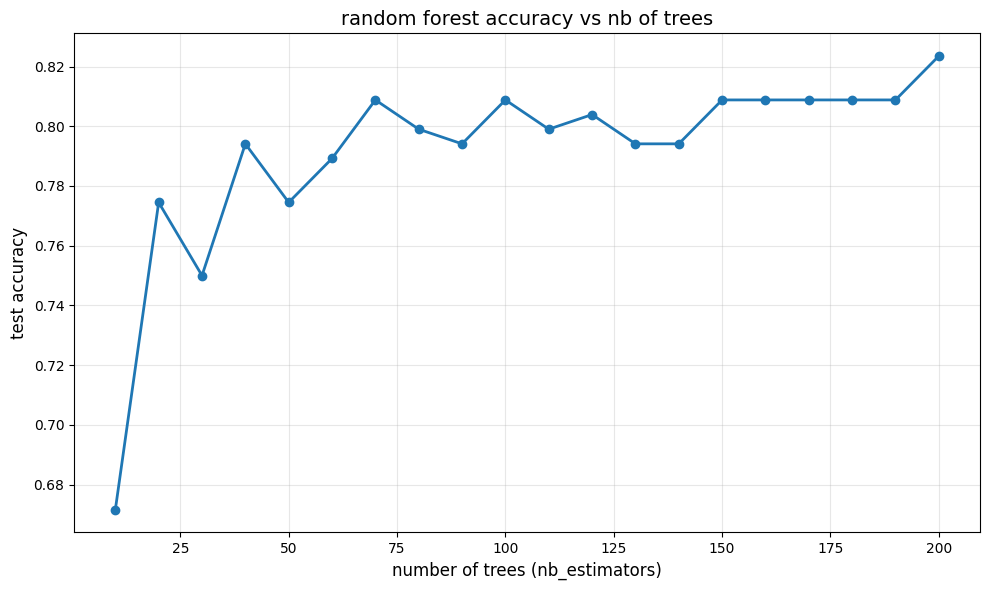

best number of trees:  200
best accuracy: 0.8235294117647058
10 to 200 trees: 0.1520


In [9]:
# Use this cell for your code

import matplotlib.pyplot as plt
n_estimators_range = np.linspace(10, 200, 20, dtype=int)
accuracies = []

for n_trees in n_estimators_range:
    rf_model = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf_model.fit(training_data, train_target)
    predicted_rf = rf_model.predict(test_data)
    accuracy = accuracy_score(test_target, predicted_rf)
    accuracies.append(accuracy)
    
    print(f"nb_estimators = {n_trees:3d}, accuracy = {accuracy:.4f}")

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, accuracies, marker='o', linewidth=2, markersize=6)
plt.xlabel('number of trees (nb_estimators)', fontsize=12)
plt.ylabel('test accuracy', fontsize=12)
plt.title('random forest accuracy vs nb of trees', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_idx = np.argmax(accuracies)
best_n_trees = n_estimators_range[best_idx]
best_accuracy = accuracies[best_idx]

print("best number of trees: ",best_n_trees)
print("best accuracy:",best_accuracy)
print(f"10 to 200 trees: {accuracies[-1] - accuracies[0]:.4f}")

3. If we had picked the amount of decision trees by taking the value with the best test accuracy from the last plot, we would have *overfit* our hyperparameters to the test data. Can you see why it is a mistake to tune hyperparameters of your model by using the test data?

*You can use this markdown cell to write down your thoughts.*
the pb is that we are learning from the test data.
and the hyperparameters chosen might work here but not in general


4. Reshuffle and resplit the data so that it is divided in 3 parts: training (80%), validation (10%) and test (10%). Repeatedly train a model of your choosing (e.g random forest) on the training data, and evaluate it’s performance on the validation set, while tuning the hyperparameters so that the accuracy on the validation set increases. Then, finally evaluate the performance of your model on the test data. What can you say in terms of the generalization of your model?

n_estimators= 10 | Train: 0.9963 | Val: 0.6863
n_estimators= 30 | Train: 1.0000 | Val: 0.7647
n_estimators= 50 | Train: 1.0000 | Val: 0.8039
n_estimators= 70 | Train: 1.0000 | Val: 0.8333
n_estimators=100 | Train: 1.0000 | Val: 0.8137
n_estimators=150 | Train: 1.0000 | Val: 0.8235
n_estimators=200 | Train: 1.0000 | Val: 0.8431

best n_estimators: 200

final model accuracies:
Train: 1.0000
Val:   0.8431
Test:  0.8039


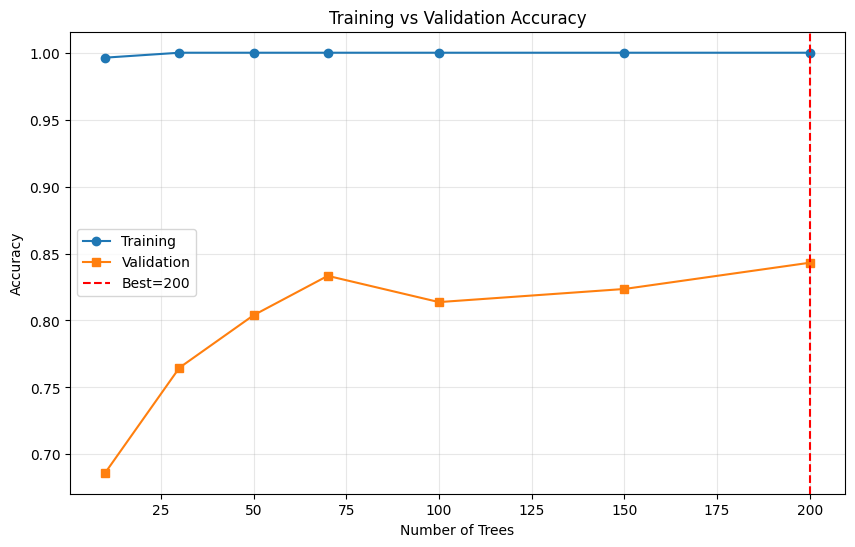

In [10]:
# Use this cell for your code


train_data, temp_data, train_target, temp_target = train_test_split(
    img_data, targets, train_size=0.8, random_state=42
)
val_data, test_data, val_target, test_target = train_test_split(
    temp_data, temp_target, train_size=0.5, random_state=42
)
n_estimators_range = [10, 30, 50, 70, 100, 150, 200]
val_accuracies = []
train_accuracies = []

for n_trees in n_estimators_range:
    rf_model = RandomForestClassifier(n_estimators=n_trees, random_state=42)
    rf_model.fit(train_data, train_target)
    
    train_acc = accuracy_score(train_target, rf_model.predict(train_data))
    val_acc = accuracy_score(val_target, rf_model.predict(val_data))
    
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)
    
    print(f"n_estimators={n_trees:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f}")

best_n_trees = n_estimators_range[np.argmax(val_accuracies)]
print(f"\nbest n_estimators: {best_n_trees}")

final_model = RandomForestClassifier(n_estimators=best_n_trees, random_state=42)
final_model.fit(train_data, train_target)

train_acc_final = accuracy_score(train_target, final_model.predict(train_data))
val_acc_final = accuracy_score(val_target, final_model.predict(val_data))
test_acc_final = accuracy_score(test_target, final_model.predict(test_data))

print("\nfinal model accuracies:")
print(f"Train: {train_acc_final:.4f}")
print(f"Val:   {val_acc_final:.4f}")
print(f"Test:  {test_acc_final:.4f}")

#claude for the plotting
plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_accuracies, marker='o', label='Training')
plt.plot(n_estimators_range, val_accuracies, marker='s', label='Validation')
plt.axvline(x=best_n_trees, color='red', linestyle='--', label=f'Best={best_n_trees}')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 3 | TPOT

The process of picking a suitable model, evaluating its performance and tuning the hyperparameters is very time consuming. A new idea in machine learning is the concept of automating this by using an optimization algorithm to find the best model in the space of models and their hyperparameters. Have a look at [TPOT](https://github.com/EpistasisLab/tpot), an automated ML solution that finds a good model and a good set of hyperparameters automatically. Try it on this data, it should outperform simple models like the ones we tried easily. Note that running the algorithm might take a while, depending on the strength of your computer. 

*Note*: In case it is running for too long, try checking if the parameters you are using when calling TPOT are reasonable, i.e. try reducing number of ‘generations’ or ‘population_size’. TPOT uses cross-validation internally, so we don’t need our own validation set.

In [14]:
# Use this cell for your code

from tpot import TPOTClassifier


X_train, X_test, y_train, y_test = train_test_split(
    img_data, targets, train_size=0.8, random_state=42
)

tpot = TPOTClassifier(verbose=2, max_time_mins=20, max_eval_time_mins=5, population_size=20)

tpot.fit(X_train, y_train)

y_pred = tpot.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred)

print(f"\nTPOT test Accuracy: {test_accuracy:.4f}") #0 ???

print("\ncomparison:")
print("Random Forest (tuned): 0.8039")
print("TPOT AutoML:",test_accuracy)


/Users/nawara/Documents/exchange/introDS/venv/lib/python3.13/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 50396 instead
  warnings.warn(
/Users/nawara/Documents/exchange/introDS/venv/lib/python3.13/site-packages/tpot/tpot_estimator/estimator.py:537: UserWarning: Labels are not encoded as ints from 0 to N. For compatibility with some classifiers such as sklearn, TPOT has encoded y with the sklearn LabelEncoder. When using pipelines outside the main TPOT estimator class, you can encode the labels with est.label_encoder_
  warnings.warn("Labels are not encoded as ints from 0 to N. For compatibility with some classifiers such as sklearn, TPOT has encoded y with the sklearn LabelEncoder. When using pipelines outside the main TPOT estimator class, you can encode the labels with est.label_encoder_")

0it [00:00, ?it/s]
Generation: : 0it [00:00, ?it/s]/Users/nawara/Documents/exchange


TPOT test Accuracy: 0.0000

Comparison:
Random Forest (tuned): 0.8039
TPOT AutoML:          0.0000


**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**